# CodeAlpha Internship – Task 3  
## Data Visualization with Python  

**Objective:**  
To analyze and visualize restaurant tipping behavior using the Tips dataset.  
We will create different plots to identify patterns and relationships in the data.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [7]:
# Load the built-in tips dataset
df = sns.load_dataset('tips')

# Display first 5 rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


The dataset contains 244 entries and 7 columns:  
- `total_bill`: bill amount in dollars  
- `tip`: tip amount in dollars  
- `sex`: gender of the payer  
- `smoker`: whether the party included smokers  
- `day`: day of the week  
- `time`: lunch or dinner  
- `size`: number of people in the party

In [8]:
# Get basic info and statistics
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


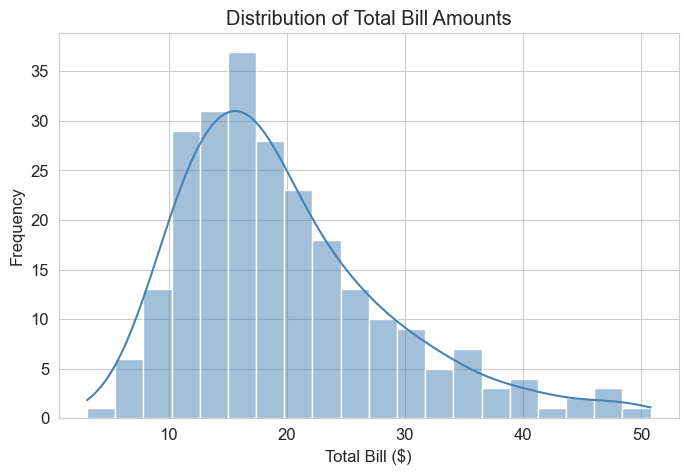

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Total Bill Amounts')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.show()

### Count of Transactions by Day and Meal Time
These plots show the frequency of transactions across different days and meal times.

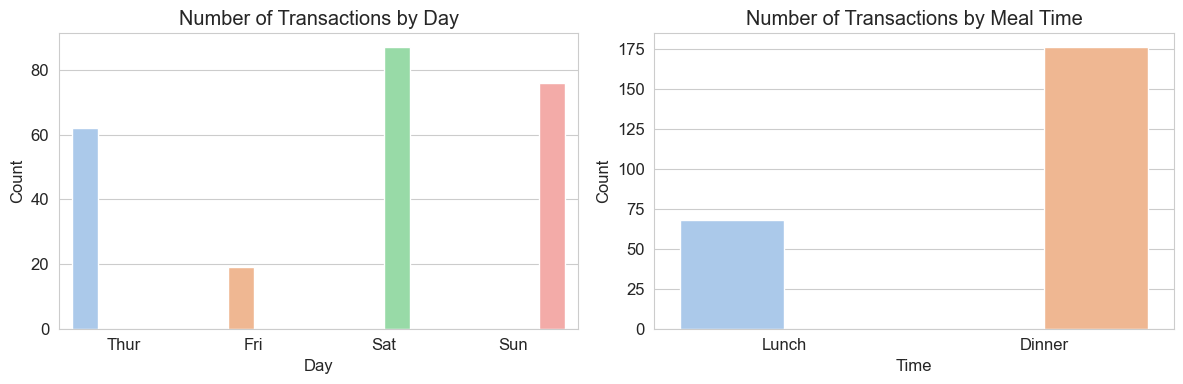

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(data=df, x='day', order=['Thur','Fri','Sat','Sun'], 
              ax=axes[0], palette='pastel', hue='day', legend=False)
axes[0].set_title('Number of Transactions by Day')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='time', ax=axes[1], palette='pastel', 
              hue='time', legend=False)
axes[1].set_title('Number of Transactions by Meal Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Insight:**  
Saturday has the highest number of transactions, followed by Sunday. Dinner is more popular than lunch, with nearly twice the number of transactions.

### Relationship Between Total Bill and Tip
This scatter plot with a regression line shows how tip amount changes with the total bill.

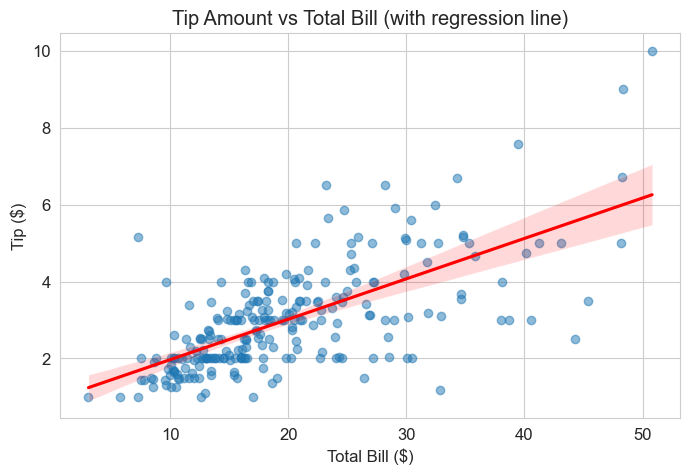

In [11]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='total_bill', y='tip', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Tip Amount vs Total Bill (with regression line)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

**Insight:**  
Saturday has the highest number of transactions, followed by Sunday. Dinner is more popular than lunch, with nearly twice the number of transactions.

### Average Tip Amount by Day
This bar chart shows which days have the highest average tips.

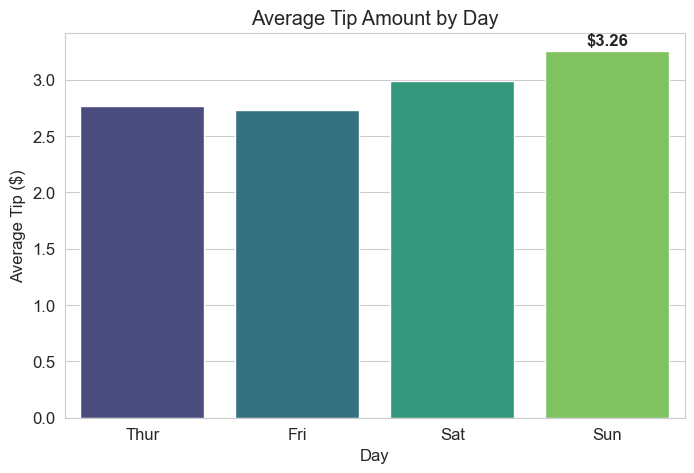

In [12]:
# Calculate average tip per day (maintain correct order)
avg_tip_day = df.groupby('day')['tip'].mean().reindex(['Thur','Fri','Sat','Sun']).reset_index()
avg_tip_day.columns = ['day', 'avg_tip']

plt.figure(figsize=(8,5))
sns.barplot(data=avg_tip_day, x='day', y='avg_tip', palette='viridis', hue='day', legend=False)
plt.title('Average Tip Amount by Day')
plt.xlabel('Day')
plt.ylabel('Average Tip ($)')

# Annotate the highest bar
max_val = avg_tip_day['avg_tip'].max()
max_day = avg_tip_day.loc[avg_tip_day['avg_tip'].idxmax(), 'day']
plt.text(max_day, max_val+0.05, f'${max_val:.2f}', ha='center', fontweight='bold')

plt.show()

**Insight:**  
Sunday receives the highest average tip ($3.25), while Friday has the lowest ($2.73). This could inform staffing or promotional strategies.

### Distribution of Total Bill by Gender
Box plots help compare the spread and central tendency of bills for male and female payers.

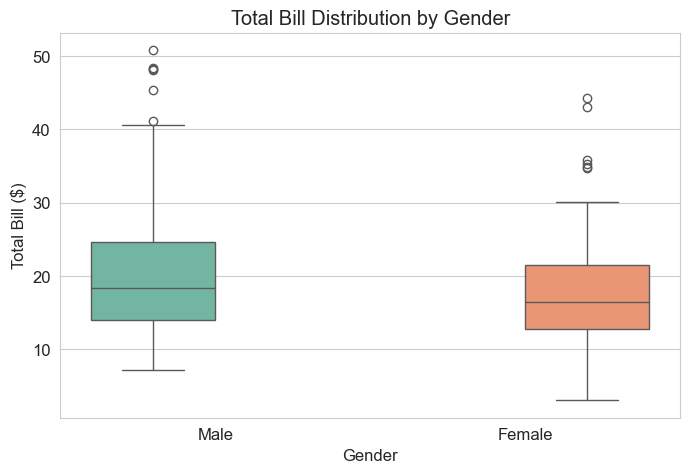

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sex', y='total_bill', palette='Set2', hue='sex', legend=False)
plt.title('Total Bill Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Bill ($)')
plt.show()

**Insight:**  
The median bill is similar for both genders, but males show slightly more variability and higher outliers. Overall, spending patterns are comparable.

### Correlation Heatmap (Numerical Features)
This heatmap shows the strength of relationships between total_bill, tip, and party size.

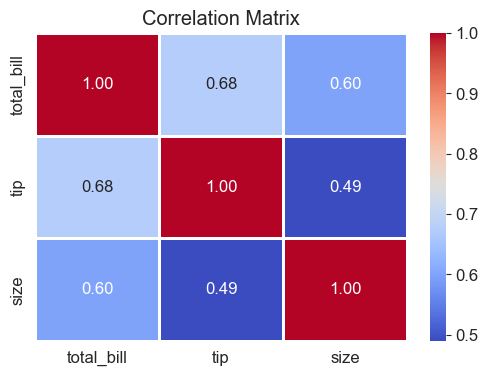

In [14]:
# Select only numeric columns
numeric_cols = ['total_bill', 'tip', 'size']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Matrix')
plt.show()

**Insight:**  
Total bill and tip are strongly correlated (0.68). Party size also correlates moderately with both bill and tip (0.49 and 0.49). This makes intuitive sense: larger groups tend to have higher bills and tips.

### Pairwise Relationships Colored by Meal Time
This pairplot gives an overview of how variables interact, with separate colors for lunch and dinner.

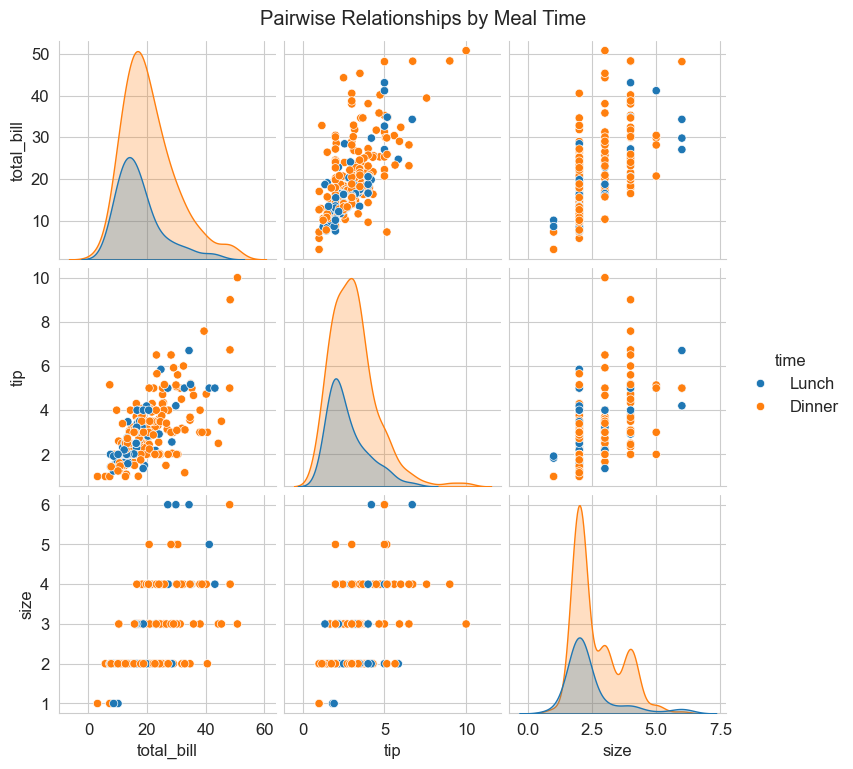

In [16]:
sns.pairplot(df[['total_bill','tip','size','time']], hue='time', diag_kind='kde')
plt.suptitle('Pairwise Relationships by Meal Time', y=1.02)
plt.show()

**Insight:**  
Dinner transactions generally have higher bills and larger party sizes compared to lunch. The distributions for tip are also slightly higher at dinner.

### Distribution of Total Bill by Day and Time (Violin Plot)
Violin plots combine box plots and KDE to show the full distribution.

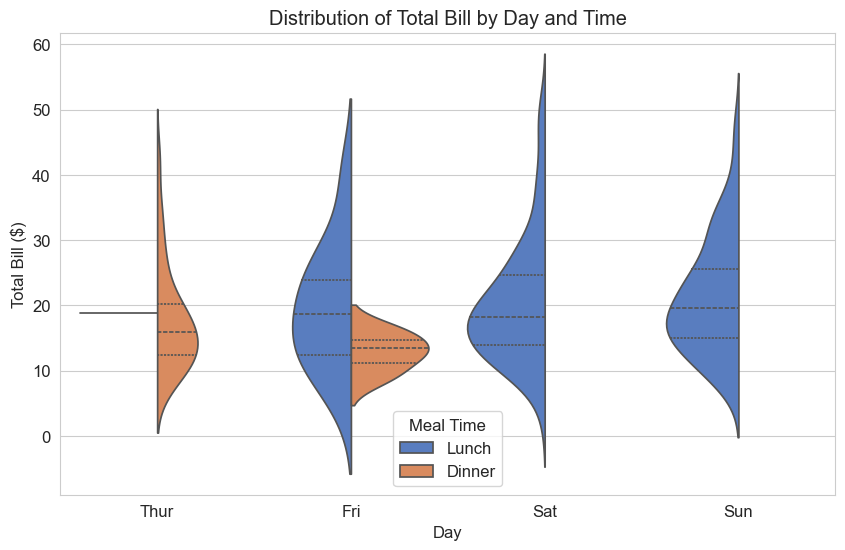

In [17]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='day', y='total_bill', hue='time', split=True, inner='quart', palette='muted')
plt.title('Distribution of Total Bill by Day and Time')
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.legend(title='Meal Time')
plt.show()

**Insight:**  
Dinner bills are consistently higher than lunch bills across all days. The widest spread occurs on Saturday dinner, indicating high variability.

## 🔍 Key Insights & Business Recommendations

Based on the visualizations, we can draw the following conclusions:

1. **Tipping Behavior**  
   - Tips increase with bill amount; larger parties tip more.  
   - Sunday generates the highest average tip – consider offering specials to boost Sunday traffic.

2. **Peak Days & Times**  
   - Saturday is the busiest day; dinner is the most popular time.  
   - Staff allocation should be highest on weekend evenings.

3. **Gender Differences**  
   - No major difference in bill amounts, but male parties show slightly more outliers.  
   - No need for gender‑specific marketing based on this data.

4. **Correlations**  
   - Strong correlation between total bill and tip suggests that increasing average bill (e.g., upselling) could directly increase tips.

These insights can help the restaurant optimize operations and increase revenue.

## Conclusion

This project analyzed restaurant tipping behavior using data visualization.

Key findings:
- Tips increase as the total bill increases.
- Dinner has more transactions than lunch.
- Saturday and Sunday are the busiest days.
- Larger groups tend to generate higher bills and tips.

These insights can help restaurants optimize staffing and marketing strategies.## Conclusion

This project analyzed restaurant tipping behavior using data visualization.

Key findings:
- Tips increase as the total bill increases.
- Dinner has more transactions than lunch.
- Saturday and Sunday are the busiest days.
- Larger groups tend to generate higher bills and tips.

These insights can help restaurants optimize staffing and marketing strategies.